In [1]:
#data collection
import pandas as pd

df = pd.read_csv(r"D:\Sentiment_Mental_health_dataset.csv")

print(df.head())

                                           statement                status
0  Anyone else have symptoms much improved after ...               Bipolar
1  I basicaly do not exist, sure feels that way. ...              Suicidal
2  Finding a sense of self It's like one minute I...  Personality_disorder
3  Putting into words what were just tangles in m...               Anxiety
4  Anxiety makes me worry about my public image s...               Anxiety


In [2]:
df.columns = ["text", "label"]

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26350 entries, 0 to 26349
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    26350 non-null  object
 1   label   26350 non-null  object
dtypes: object(2)
memory usage: 411.8+ KB
None


In [4]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [5]:
print(df.duplicated().sum())

17


In [6]:
df = df.drop_duplicates()

In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df['label'].unique())

['Bipolar' 'Suicidal' 'Personality_disorder' 'Anxiety' 'Depression'
 'Stress' 'Normal']


In [9]:
print(df['label'].value_counts())

label
Suicidal                5592
Anxiety                 4704
Normal                  4574
Depression              4111
Personality_disorder    2810
Bipolar                 2720
Stress                  1822
Name: count, dtype: int64


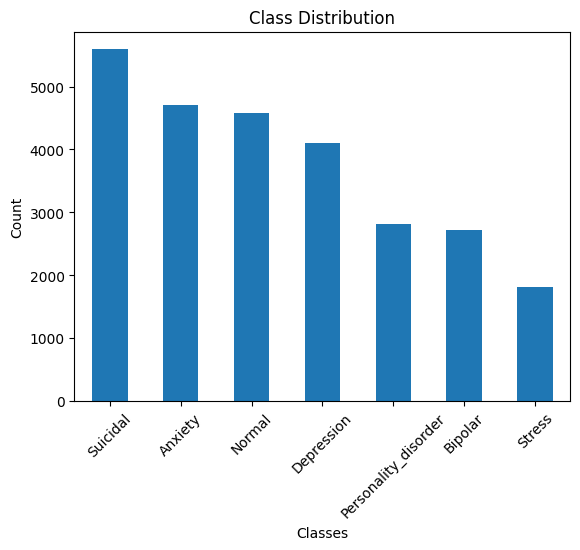

In [10]:
#EDA
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

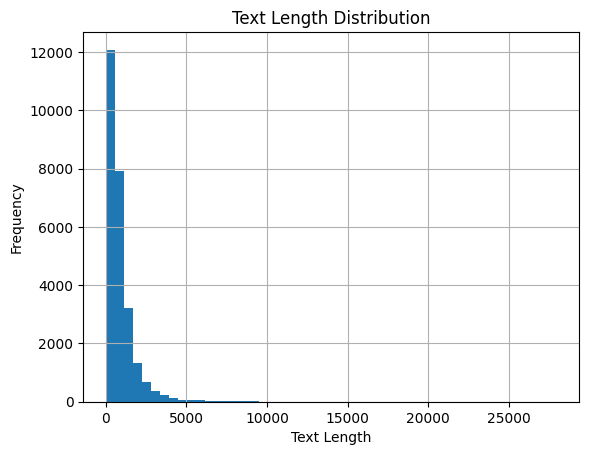

In [11]:
df['text_length'] = df['text'].apply(len)

df['text_length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [12]:
print(df['text_length'].describe())

count    26333.000000
mean       908.390537
std       1144.513479
min          1.000000
25%        338.000000
50%        615.000000
75%       1093.000000
max      27963.000000
Name: text_length, dtype: float64


In [13]:
from collections import Counter
import re

all_text = " ".join(df['text'])

words = re.findall(r'\w+', all_text.lower())

common_words = Counter(words).most_common(20)

print(common_words)

[('i', 313559), ('to', 147045), ('and', 138399), ('the', 100424), ('a', 94186), ('my', 88395), ('it', 71662), ('of', 67077), ('t', 53167), ('that', 52179), ('me', 50235), ('in', 49161), ('m', 45005), ('for', 43333), ('but', 42535), ('is', 41736), ('have', 39514), ('this', 36892), ('with', 34510), ('just', 32186)]


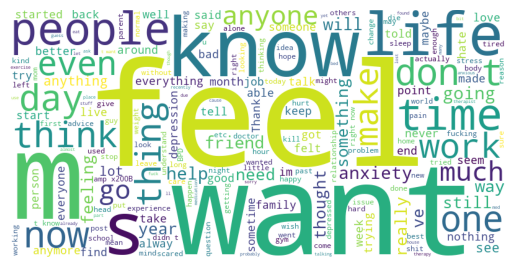

In [14]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [15]:
for label in df['label'].unique():
    subset = df[df['label'] == label]
    print(f"{label}: {len(subset)} samples")

Bipolar: 2720 samples
Suicidal: 5592 samples
Personality_disorder: 2810 samples
Anxiety: 4704 samples
Depression: 4111 samples
Stress: 1822 samples
Normal: 4574 samples


In [16]:
print(df.sample(5))

                                                    text       label  \
3923   Sertraline 50mg Currently taking sertraline 50...     Anxiety   
1577   Stupid fucking broken ass brain to whoever mad...    Suicidal   
18954  Any ever get tried of there life. It feels lik...  Depression   
11465  Not Trying to be Preachy Everyone is absolutel...  Depression   
25927  Too anxious for anything sexual? Does anyone e...     Anxiety   

       text_length  
3923           406  
1577           162  
18954          709  
11465         1275  
25927          354  


In [17]:
#Streaming Simulation Loop
df_stream = df.sample(frac=1).reset_index(drop=True).head(200)

In [18]:
import time

def stream_data(data, delay=0.01):
    for i, row in data.iterrows():
        text = row['text']
        label = row['label']
        
        print(f"[{i}] {text}")
        
        time.sleep(delay)

In [19]:
stream_data(df_stream, delay=0.01)

[0] Anxiety Does anybody else get anxiety when nobody reads their previous post?
[1] I have many questions and I've reviewed the Wiki's My biggest problem is that so many places have different info. Here's my story. 

328lbs as of this morning. Type 2 Diabetic, managed through diet and lifestyle changes. I've come down from 357lbs since December and 376lbs in Summer of last year. I also have low testosterone and cannot afford the monthly medication that I'm aware of. I'm going to talk to my doctor about that. The low T was from before I started lifting. 

Losing weight isn't such a big deal. I am obviously working on that and it will continue to happen (30 min of cardio, 5 days a week, high intensity, heart rate ranging from 151 to 161, max should be 184, travel roughly 3 miles and burn roughly 450 calories a day). What I've really been working on is resistance machines to increase muscle mass (to be pretty and also to prevent as much loose skin from forming as possible) but I've been 

In [20]:
def stream_generator(data):
    for _, row in data.iterrows():
        yield row['text'], row['label']

In [21]:
for text, label in stream_generator(df_stream):
    print(text)
    time.sleep(0.01)

Anxiety Does anybody else get anxiety when nobody reads their previous post?
I have many questions and I've reviewed the Wiki's My biggest problem is that so many places have different info. Here's my story. 

328lbs as of this morning. Type 2 Diabetic, managed through diet and lifestyle changes. I've come down from 357lbs since December and 376lbs in Summer of last year. I also have low testosterone and cannot afford the monthly medication that I'm aware of. I'm going to talk to my doctor about that. The low T was from before I started lifting. 

Losing weight isn't such a big deal. I am obviously working on that and it will continue to happen (30 min of cardio, 5 days a week, high intensity, heart rate ranging from 151 to 161, max should be 184, travel roughly 3 miles and burn roughly 450 calories a day). What I've really been working on is resistance machines to increase muscle mass (to be pretty and also to prevent as much loose skin from forming as possible) but I've been reading 

In [22]:
def stream_batches(data, batch_size=10):
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size]

In [23]:
for batch in stream_batches(df_stream, 10):
    print(batch[['text', 'label']])
    time.sleep(0.1)

                                                text                 label
0  Anxiety Does anybody else get anxiety when nob...               Anxiety
1  I have many questions and I've reviewed the Wi...                Normal
2  I've been depressed since I was maybe 12??? no...              Suicidal
3  considering checking myself into the psych war...            Depression
4  Depression isn’t Helping My Relationship With ...            Depression
5  How do you stop yourself from being impulsive?...  Personality_disorder
6  Be extremely honest I have the hardest time ov...               Anxiety
7  Anxiety attacks. Cannot get through a nights s...               Anxiety
8  Hello reddit. I don't know where else to turn....                Stress
9  Do I blame the disorder or myself? I was manic...               Bipolar
                                                 text                 label
10  Is there any disadvantage of going to the gym ...                Normal
11  I'm never depressed

## Text Preprocessing

In [24]:
import re
import nltk
from nltk.corpus import stopwords ,wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag


def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # remove links
    text = re.sub(r'@\w+', '', text)  # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  Anyone else have symptoms much improved after ...   
1  I basicaly do not exist, sure feels that way. ...   
2  Finding a sense of self It's like one minute I...   
3  Putting into words what were just tangles in m...   
4  Anxiety makes me worry about my public image s...   

                                          clean_text  
0  anyone else have symptoms much improved after ...  
1  i basicaly do not exist sure feels that way no...  
2  finding a sense of self its like one minute im...  
3  putting into words what were just tangles in m...  
4  anxiety makes me worry about my public image s...  


In [25]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_text)

print(df[['clean_text', 'tokens']].head())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                          clean_text  \
0  anyone else have symptoms much improved after ...   
1  i basicaly do not exist sure feels that way no...   
2  finding a sense of self its like one minute im...   
3  putting into words what were just tangles in m...   
4  anxiety makes me worry about my public image s...   

                                              tokens  
0  [anyone, else, symptoms, much, improved, leavi...  
1  [basicaly, exist, sure, feels, way, friends, r...  
2  [finding, sense, self, like, one, minute, im, ...  
3  [putting, words, tangles, brain, chronic, anxi...  
4  [anxiety, makes, worry, public, image, damn, m...  


In [26]:
nltk.download('averaged_perceptron_tagger_eng')
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(tokens):
    pos_tags = pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_text)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hana\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [27]:
print(df[['tokens', 'lemmatized']].head())

                                              tokens  \
0  [anyone, else, symptoms, much, improved, leavi...   
1  [basicaly, exist, sure, feels, way, friends, r...   
2  [finding, sense, self, like, one, minute, im, ...   
3  [putting, words, tangles, brain, chronic, anxi...   
4  [anxiety, makes, worry, public, image, damn, m...   

                                          lemmatized  
0  [anyone, else, symptoms, much, improve, leave,...  
1  [basicaly, exist, sure, feel, way, friend, rea...  
2  [find, sense, self, like, one, minute, im, one...  
3  [put, word, tangle, brain, chronic, anxiety, t...  
4  [anxiety, make, worry, public, image, damn, mu...  


In [28]:
df.to_csv("cleaned_sentiment_dataset.csv", index=False)